<a href="https://colab.research.google.com/github/Saadmoquim/physicscode/blob/main/RK4_and_euler_cromer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Fourth-Order Runge–Kutta (RK4) Scheme**

Consider a system of first-order ordinary differential equations:
$$
\frac{d\mathbf{y}}{dt} = \mathbf{f}(t,\mathbf{y}),
$$
with initial condition $$ \mathbf{y}(t_0) = \mathbf{y}_0 .$$

Let the time step be  $$\Delta t$$ , and define
$$
t_{n+1} = t_n + \Delta t.
$$

---

### RK4 Update Formula

Starting from $$ (t_n, \mathbf{y}_n) $$, compute four intermediate slopes:

$$
\begin{aligned}
\mathbf{k}_1 &= \Delta t \, \mathbf{f}(t_n, \mathbf{y}_n), \\[6pt]
\mathbf{k}_2 &= \Delta t \, \mathbf{f}\!\left(t_n + \frac{\Delta t}{2},
\mathbf{y}_n + \frac{\mathbf{k}_1}{2}\right), \\[6pt]
\mathbf{k}_3 &= \Delta t \, \mathbf{f}\!\left(t_n + \frac{\Delta t}{2},
\mathbf{y}_n + \frac{\mathbf{k}_2}{2}\right), \\[6pt]
\mathbf{k}_4 &= \Delta t \, \mathbf{f}(t_n + \Delta t,
\mathbf{y}_n + \mathbf{k}_3).
\end{aligned}
$$

The solution at the next time step is then given by
$$
\mathbf{y}_{n+1}
=
\mathbf{y}_n
+
\frac{1}{6}
\left(
\mathbf{k}_1
+
2\mathbf{k}_2
+
2\mathbf{k}_3
+
\mathbf{k}_4
\right).
$$

---

### Accuracy

- Local truncation error: $$ \mathcal{O}(\Delta t^5) $$
- Global error: $$ \mathcal{O}(\Delta t^4) $$

---

### Remarks

- RK4 is an explicit, single-step method
- Provides high accuracy for smooth solutions
- Not symplectic, so long-time energy conservation is not guaranteed


input maximum runtime:100
input time step:0.1
input natural frequency:10
input damping coefficient:0
input initial displacement:10
input initial velocity:0


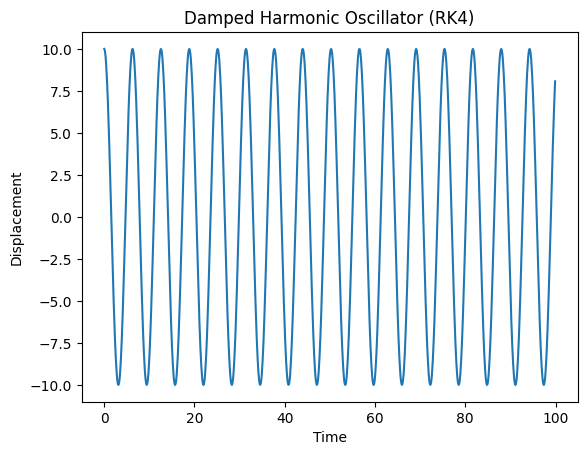

In [8]:
import numpy as np
import matplotlib.pyplot as plt

t_max=int(input("input maximum runtime:",))
h=float(input("input time step:",))
omega=float(input("input natural frequency:",))
gamma=float(input("input damping coefficient:",))


t=np.arange(0,t_max,h)
x=np.zeros(len(t))
v=np.zeros(len(t))

x[0]=float(input("input initial displacement:",))
v[0]=float(input("input initial velocity:",))

for i in range(len(t)-1):

    def fx(x, v):
        return v

    def fv(x, v):
        return -gamma*v - omega0**2 * x

    k1x = h * fx(x[i], v[i])
    k1v = h * fv(x[i], v[i])

    k2x = h * fx(x[i] + k1x/2, v[i] + k1v/2)
    k2v = h * fv(x[i] + k1x/2, v[i] + k1v/2)

    k3x = h * fx(x[i] + k2x/2, v[i] + k2v/2)
    k3v = h * fv(x[i] + k2x/2, v[i] + k2v/2)

    k4x = h * fx(x[i] + k3x, v[i] + k3v)
    k4v = h * fv(x[i] + k3x, v[i] + k3v)

    x[i+1] = x[i] + (k1x + 2*k2x + 2*k3x + k4x)/6
    v[i+1] = v[i] + (k1v + 2*k2v + 2*k3v + k4v)/6

# Plot
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.title("Damped Harmonic Oscillator (RK4)")
plt.show()

input time step:0.001
input maximum runtime:100
input initial condition:10


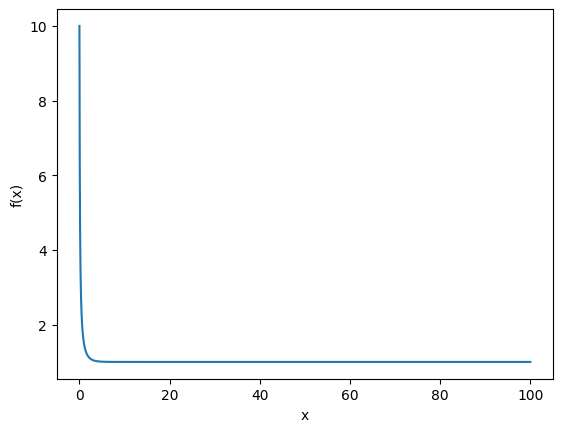

In [16]:
import numpy as np
import matplotlib.pyplot as plt

dt=float(input("input time step:",))
t_max=int(input("input maximum runtime:",))

t=np.arange(0,t_max,dt)
x=np.zeros(len(t))

x[0]=float(input("input initial condition:",))

def f(x):
  return x*(1-x)

for i in range(len(t)-1):
  k_1=dt*f(x[i])
  k_2=dt*f(x[i]+k_1/2)
  k_3=dt*f(x[i]+k_2/2)
  k_4=dt*f(x[i]+k_3)

  x[i+1]=x[i]+(k_1+2*k_2+2*k_3+k_4)/6

plt.plot(t,x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()